# DroneRF Classic Machine Learning High School Project

**Goal:** Learn what classic machine learning models and neural networks are and how to use them on a drone radio-frequency dataset.

This notebook is designed for a **10-week high school research project**.

## What this notebook includes

1. Setup and path configuration  
2. Demo 1: database details  
3. Demo 2: raw signal snippets  
4. Main 1: raw RF aggregation using FFT  
5. Demo 3: spectrum analysis  
6. Main 2: data labeling into `RF_Data.csv`  
7. Small subset creation  
8. Classic ML model showcase:
   - Random Forest
   - Support Vector Machine
   - Gaussian Naive Bayes
   - Logistic Regression
   - K-Nearest Neighbors
9. DNN classification
10. Model comparison and confusion matrices  
11. Final reflection questions

## Important note about dataset size

The full DroneRF dataset is large. For classroom use, this notebook lets you process only a **small subset** of the raw data first. This is much faster and is appropriate for demonstrating classic ML models.

# 0. 10-Week Project Roadmap

| Week | Focus | What students do |
|---|---|---|
| 1 | Introduction | Learn what RF signals and drone detection are |
| 2 | Dataset setup | Download/extract data and inspect files |
| 3 | Signal preprocessing | Convert raw signals into frequency-domain features |
| 4 | Exploratory analysis | Plot snippets and spectra |
| 5 | Labels and supervised learning | Build `RF_Data.csv` with features and labels |
| 6 | Baseline ML models | Train Gaussian Naive Bayes and Logistic Regression |
| 7 | Stronger ML models | Train Random Forest, SVM, KNN and DNN |
| 8 | Evaluation | Compare accuracy, F1-score, and confusion matrices |
| 9 | Improvement | Try different subset sizes or classification levels |
| 10 | Final deliverable | Prepare poster, report, or presentation |

# 1. Setup

Run this first. It imports libraries and defines helper functions.

It also extracts the data from the zip file.

In [35]:
from pathlib import Path
from collections import Counter
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import savemat, loadmat
from scipy.signal import savgol_filter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

RANDOM_STATE = 42

def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def check_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return path

def find_csv_file(load_directory, filename):
    # Search recursively because extracted RAR files may create nested folders.
    load_directory = Path(load_directory)
    matches = list(load_directory.rglob(filename))
    if len(matches) == 0:
        raise FileNotFoundError(f"Could not find {filename} anywhere inside {load_directory}")
    return matches[0]

def print_section(title):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

In [2]:
from google.colab import drive
from pathlib import Path
import os
import zipfile
import shutil

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Set your paths
ZIP_PATH = Path("/content/drive/MyDrive/DroneRF/data.zip")
ZIP_EXTRACT_DIR = Path("/content/drone_rf_zip_extracted")
RAW_DIR = Path("/content/drone_rf_raw_csv")
RESULTS_DIR = Path("/content/drive/MyDrive/DroneRF/results2")

# 3. Create folders
ZIP_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 4. Extract the main zip file
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(ZIP_EXTRACT_DIR)

print("Main zip extracted to:", ZIP_EXTRACT_DIR)

# 5. Install unrar
!apt-get update -qq
!apt-get install unrar -y

# 6. Find all RAR files inside extracted zip folder
rar_files = list(ZIP_EXTRACT_DIR.rglob("*.rar"))

print("Found RAR files:", len(rar_files))

# 7. Extract all RAR files into RAW_DIR
for rar_file in rar_files:
    print("Extracting:", rar_file.name)
    os.system(f'unrar x -o+ "{rar_file}" "{RAW_DIR}/"')

print("All RAR files extracted.")

# 8. Check if CSV files exist
csv_files = list(RAW_DIR.rglob("*.csv"))

print("Found CSV files:", len(csv_files))
print("First 10 CSV files:")
for f in csv_files[:10]:
    print(f)

# 9. Final paths for the pipeline notebook
print("\nUse these paths in your notebook:")
print("RAW_DIR =", RAW_DIR)
print("RESULTS_DIR =", RESULTS_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Main zip extracted to: /content/drone_rf_zip_extracted
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 7 not upgraded.
Found RAR files: 23
Extracting: RF Data_10000_L.rar
Extracting: RF Data_10010_H.rar
Extracting: RF Data_10001_H.rar
Extracting: RF Data_10010_L.rar
Extracting: RF Data_10001_L.rar
Extracting: RF Data_10000_H.rar
Extracting: RF Data_10011_L.rar
Extracting: RF Data_10011_H.rar
Extracting: FR Data_00000_H2.rar
Extracting: RF Data_00000_L1.rar
Extracting: RF Data_00000_L2.rar
Extracting: RF Data_00000_H1.rar
E

# 2. Change Paths Here

Set `RAW_DIR` to the folder that contains or contains subfolders with files like:

```text
00000L_0.csv
00000H_0.csv
10000L_0.csv
10000H_0.csv
```

Set `RESULTS_DIR` to the folder where generated files should be saved.

In [3]:
# -------- CHANGE THESE PATHS --------
RAW_DIR = Path("/content/drone_rf_raw_csv")         # raw CSV folder, can contain nested folders
RESULTS_DIR = Path("/content/drive/MyDrive/DroneRF/results2")  # save outputs here

RAW_DIR = Path(RAW_DIR)
RESULTS_DIR = ensure_dir(RESULTS_DIR)

print("RAW_DIR:", RAW_DIR.resolve())
print("RESULTS_DIR:", RESULTS_DIR.resolve())

# Quick check
csv_files = list(RAW_DIR.rglob("*.csv"))
print("Number of CSV files found:", len(csv_files))
print("First few CSVs:")
for f in csv_files[:10]:
    print(" -", f)

RAW_DIR: /content/drone_rf_raw_csv
RESULTS_DIR: /content/drive/MyDrive/DroneRF/results2
Number of CSV files found: 454
First few CSVs:
 - /content/drone_rf_raw_csv/11000L_11.csv
 - /content/drone_rf_raw_csv/00000H_0.csv
 - /content/drone_rf_raw_csv/00000H_10.csv
 - /content/drone_rf_raw_csv/00000H_5.csv
 - /content/drone_rf_raw_csv/00000H_14.csv
 - /content/drone_rf_raw_csv/00000H_2.csv
 - /content/drone_rf_raw_csv/11000L_7.csv
 - /content/drone_rf_raw_csv/00000H_8.csv
 - /content/drone_rf_raw_csv/11000L_20.csv
 - /content/drone_rf_raw_csv/11000L_16.csv


# 3. Dataset Class Groups

The original DroneRF scripts use 10 BUI codes. These represent background and different drone activities.

The project has three classification levels:

- **Level 1:** Drone vs Background
- **Level 2:** Bebop vs AR vs Phantom vs Background
- **Level 3:** 10 detailed classes

In [4]:
BUI_GROUPS = [
    ['00000'],                                  # Background
    ['10000', '10001', '10010', '10011'],      # Bebop
    ['10100', '10101', '10110', '10111'],      # AR
    ['11000']                                  # Phantom
]

BUI_FLAT = ['00000', '10000', '10001', '10010', '10011',
            '10100', '10101', '10110', '10111', '11000']

LEVEL1_NAMES = ["Drone", "Background"]
LEVEL2_NAMES = ["Bebop", "AR", "Phantom", "Background"]
LEVEL3_NAMES = ['10000', '10001', '10010', '10011',
                '10100', '10101', '10110', '10111',
                '11000', '00000']

# 4. Demo 1: Database Details

This section counts how many files/samples belong to each class and prints three tables:

1. Level 1: Drone vs Background  
2. Level 2: Bebop vs AR vs Phantom vs Background  
3. Level 3: Detailed 10-class labels  

**Column meaning:**

1. Adjusted segment/file count  
2. Estimated raw samples  
3. Class percentage

In [6]:
# =========================
# 4. Demo 1: database details
# =========================

def demo1_database_details(load_directory=RAW_DIR):

    load_directory = Path(load_directory)

    np.set_printoptions(precision=4, suppress=True)

    # Parameters
    BUI = [
        '00000',
        '10000',
        '10001',
        '10010',
        '10011',
        '10100',
        '10101',
        '10110',
        '10111',
        '11000'
    ]

    N_seg = 1e7

    # Counting
    c = np.zeros(len(BUI))
    csv_files = list(load_directory.rglob("*.csv"))

    for i in range(len(BUI)):
        c[i] = len([f for f in csv_files if f.name.startswith(BUI[i])])

    # Level 1 details
    L1 = np.zeros(2)
    L1[0] = N_seg * np.sum(c[1:])
    L1[1] = N_seg * c[0]
    P1 = 100 * L1 / np.sum(L1)

    print("Level 1 order: [Drone, Background]")
    print(np.column_stack((L1 / N_seg / 2, L1, P1)))

    # Level 2 details
    L2 = np.zeros(4)
    L2[0] = N_seg * np.sum(c[1:5])
    L2[1] = N_seg * np.sum(c[5:9])
    L2[2] = N_seg * c[9]
    L2[3] = N_seg * c[0]
    P2 = 100 * L2 / np.sum(L2)

    print("\nLevel 2 order: [Bebop, AR, Phantom, Background]")
    print(np.column_stack((L2 / N_seg / 2, L2, P2)))

    # Level 3 details
    L3 = np.zeros(10)
    L3[0] = N_seg * c[1]
    L3[1] = N_seg * c[2]
    L3[2] = N_seg * c[3]
    L3[3] = N_seg * c[4]
    L3[4] = N_seg * c[5]
    L3[5] = N_seg * c[6]
    L3[6] = N_seg * c[7]
    L3[7] = N_seg * c[8]
    L3[8] = N_seg * c[9]
    L3[9] = N_seg * c[0]
    P3 = 100 * L3 / np.sum(L3)

    print("\nLevel 3 order:")
    print("[10000, 10001, 10010, 10011, 10100, 10101, 10110, 10111, 11000, 00000]")
    print(np.column_stack((L3 / N_seg / 2, L3, P3)))

# Run Demo 1
demo1_database_details()

Level 1 order: [Drone, Background]
[[1.8600e+02 3.7200e+09 8.1938e+01]
 [4.1000e+01 8.2000e+08 1.8062e+01]]

Level 2 order: [Bebop, AR, Phantom, Background]
[[8.4000e+01 1.6800e+09 3.7004e+01]
 [8.1000e+01 1.6200e+09 3.5683e+01]
 [2.1000e+01 4.2000e+08 9.2511e+00]
 [4.1000e+01 8.2000e+08 1.8062e+01]]

Level 3 order:
[10000, 10001, 10010, 10011, 10100, 10101, 10110, 10111, 11000, 00000]
[[2.1000e+01 4.2000e+08 9.2511e+00]
 [2.1000e+01 4.2000e+08 9.2511e+00]
 [2.1000e+01 4.2000e+08 9.2511e+00]
 [2.1000e+01 4.2000e+08 9.2511e+00]
 [2.1000e+01 4.2000e+08 9.2511e+00]
 [2.1000e+01 4.2000e+08 9.2511e+00]
 [2.1000e+01 4.2000e+08 9.2511e+00]
 [1.8000e+01 3.6000e+08 7.9295e+00]
 [2.1000e+01 4.2000e+08 9.2511e+00]
 [4.1000e+01 8.2000e+08 1.8062e+01]]


# 5. Demo 2: Raw RF Signal Snippets

This section loads a few raw `L` and `H` signal files, normalizes them, and plots them in the time domain.

This helps students see what the raw drone RF signals look like before machine learning.

Saved: /content/drive/MyDrive/DroneRF/results2/snippet_1.pdf
Saved: /content/drive/MyDrive/DroneRF/results2/snippet_2.pdf
Saved: /content/drive/MyDrive/DroneRF/results2/snippet_3.pdf


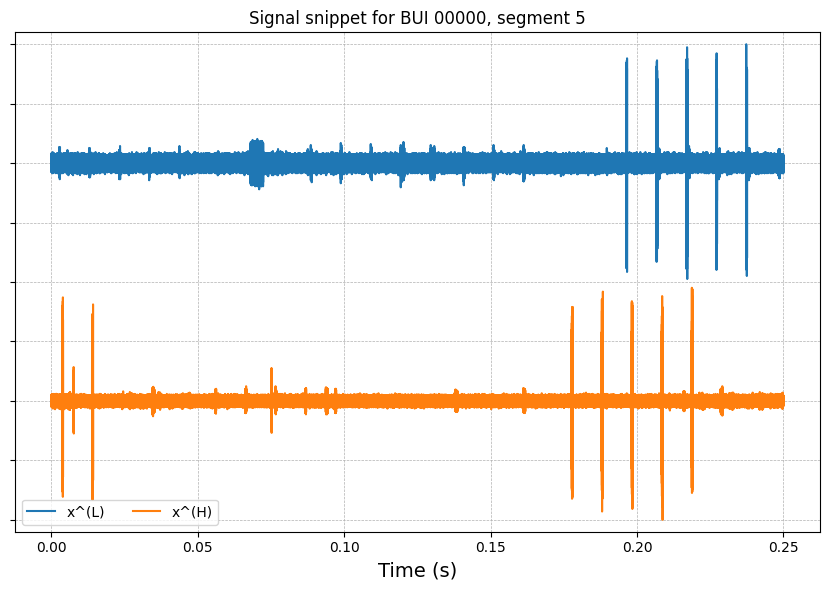

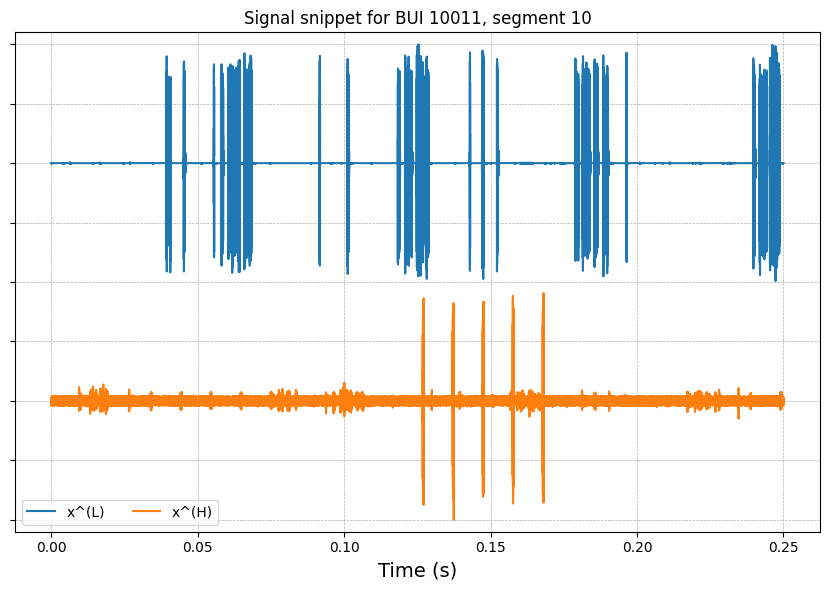

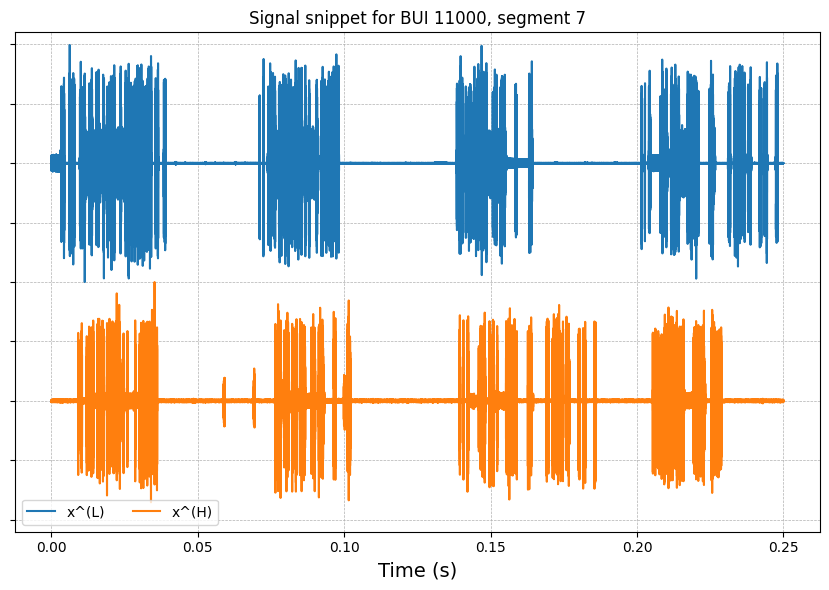

In [8]:
# =========================
# 5. Demo 2: raw RF snippets
# =========================

def demo2_snippets(load_directory=RAW_DIR, save_directory=RESULTS_DIR, save_figures=False):
    load_directory = Path(load_directory)
    save_directory = ensure_dir(save_directory)

    BUI = [
        ['00000'],
        ['10000', '10001', '10010', '10011'],
        ['10100', '10101', '10110', '10111'],
        ['11000']
    ]

    fs = 40e6

    # Original script selected:
    # background segment 5,
    # Bebop flying/video segment 10,
    # Phantom on/connected segment 7
    opt = np.array([
        [1, 1, 5],
        [2, 4, 10],
        [4, 1, 7]
    ])

    for i in range(3):
        bui = BUI[opt[i, 0] - 1][opt[i, 1] - 1]
        n = opt[i, 2]

        low_path = find_csv_file(load_directory, f"{bui}L_{n}.csv")
        high_path = find_csv_file(load_directory, f"{bui}H_{n}.csv")

        x = np.loadtxt(low_path, delimiter=',').flatten()
        y = np.loadtxt(high_path, delimiter=',').flatten()

        x = x / np.max(np.abs(x))
        y = y / np.max(np.abs(y))
        t = np.arange(0, len(x) / fs, 1 / fs)

        plt.figure(figsize=(8.4, 6), dpi=100)
        plt.plot(t, x)
        plt.plot(t, y - 2)
        plt.ylim([-3.1, 1.1])
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.xlabel('Time (s)', fontsize=14)
        plt.legend(['x^(L)', 'x^(H)'], loc='lower left', ncol=2)
        plt.gca().set_yticklabels([])
        plt.title(f"Signal snippet for BUI {bui}, segment {n}")
        plt.tight_layout()

        if save_figures:
            out = save_directory / f"snippet_{i + 1}.pdf"
            plt.savefig(out, dpi=512, bbox_inches='tight')
            print("Saved:", out)

    plt.show()

# Run Demo 2
demo2_snippets(save_figures=True)

# 6. Main 1: Raw RF Aggregation

This section does the major preprocessing step:

1. Load raw CSV files  
2. Split signals into smaller windows  
3. Convert each window into frequency-domain features using FFT  
4. Combine low and high channels  
5. Save one `.mat` file per BUI code  

## Classroom small-subset

The full dataset takes a long time. We use:

```python
main1_data_aggregation(max_segments_per_bui=2, max_windows_per_file=5)
```

That processes only a small subset but still creates the same type of output.

In [9]:
# =========================
# 6. Main 1: raw RF aggregation
# =========================

def main1_data_aggregation(
    load_directory=RAW_DIR,
    save_directory=RESULTS_DIR,
    M=2048,
    L=int(1e5),
    Q=10,
    max_segments_per_bui=2,
    max_windows_per_file=5
):
    """
    Convert raw RF CSV files into frequency-domain .mat files.

    For a fast high-school demo:
        max_segments_per_bui=2, max_windows_per_file=5

    For full original processing:
        max_segments_per_bui=None, max_windows_per_file=None
    """

    load_directory = Path(load_directory)
    save_directory = ensure_dir(save_directory)

    for group_index, group in enumerate(BUI_GROUPS):
        for bui in group:
            print("Processing BUI:", bui)

            if bui == '00000':
                N = 40
            elif bui == '10111':
                N = 17
            else:
                N = 20

            if max_segments_per_bui is None:
                segment_numbers = range(N + 1)
            else:
                segment_numbers = range(min(N + 1, max_segments_per_bui))

            data = []

            for n in segment_numbers:
                low_path = find_csv_file(load_directory, f"{bui}L_{n}.csv")
                high_path = find_csv_file(load_directory, f"{bui}H_{n}.csv")

                print(f"Loading {low_path.name} and {high_path.name}")

                x = np.loadtxt(low_path, delimiter=',')
                y = np.loadtxt(high_path, delimiter=',')

                total_windows = len(x) // L

                if max_windows_per_file is None:
                    window_numbers = range(total_windows)
                else:
                    window_numbers = range(min(total_windows, max_windows_per_file))

                for i in window_numbers:
                    # Original script used st = 1 + i*L, which skips first sample.
                    # This keeps the original behavior.
                    st = 1 + i * L
                    fi = (i + 1) * L

                    x_segment = x[st:fi] - np.mean(x[st:fi])
                    y_segment = y[st:fi] - np.mean(y[st:fi])

                    xf = np.abs(np.fft.fftshift(np.fft.fft(x_segment, M)))
                    xf = xf[len(xf) // 2:]

                    yf = np.abs(np.fft.fftshift(np.fft.fft(y_segment, M)))
                    yf = yf[len(yf) // 2:]

                    # Match spectral continuity between low/high bands
                    scale = np.mean(xf[-Q:]) / np.mean(yf[:Q])
                    combined = np.concatenate((xf, yf * scale))
                    data.append(combined)

                print(f"Finished segment {n} for {bui}")

            Data = np.array(data) ** 2
            Data = Data.T

            output_path = save_directory / f"{bui}.mat"
            savemat(output_path, {'Data': Data})
            print("Saved:", output_path, "with shape", Data.shape)

main1_data_aggregation(max_segments_per_bui=2, max_windows_per_file=5)

Processing BUI: 00000
Loading 00000L_0.csv and 00000H_0.csv
Finished segment 0 for 00000
Loading 00000L_1.csv and 00000H_1.csv
Finished segment 1 for 00000
Saved: /content/drive/MyDrive/DroneRF/results2/00000.mat with shape (2048, 10)
Processing BUI: 10000
Loading 10000L_0.csv and 10000H_0.csv
Finished segment 0 for 10000
Loading 10000L_1.csv and 10000H_1.csv
Finished segment 1 for 10000
Saved: /content/drive/MyDrive/DroneRF/results2/10000.mat with shape (2048, 10)
Processing BUI: 10001
Loading 10001L_0.csv and 10001H_0.csv
Finished segment 0 for 10001
Loading 10001L_1.csv and 10001H_1.csv
Finished segment 1 for 10001
Saved: /content/drive/MyDrive/DroneRF/results2/10001.mat with shape (2048, 10)
Processing BUI: 10010
Loading 10010L_0.csv and 10010H_0.csv
Finished segment 0 for 10010
Loading 10010L_1.csv and 10010H_1.csv
Finished segment 1 for 10010
Saved: /content/drive/MyDrive/DroneRF/results2/10010.mat with shape (2048, 10)
Processing BUI: 10011
Loading 10011L_0.csv and 10011H_0.csv


# 7. Demo 3: Spectrum Analysis

This section loads the `.mat` files from Main 1, averages the spectra, smooths them, and creates:

1. spectrum line plot  
2. boxplot  

Use `opt=1`, `opt=2`, or `opt=3` to choose the classification level.

Saved: /content/drive/MyDrive/DroneRF/results2/Spectrum_1.pdf
Saved: /content/drive/MyDrive/DroneRF/results2/Box_1.pdf


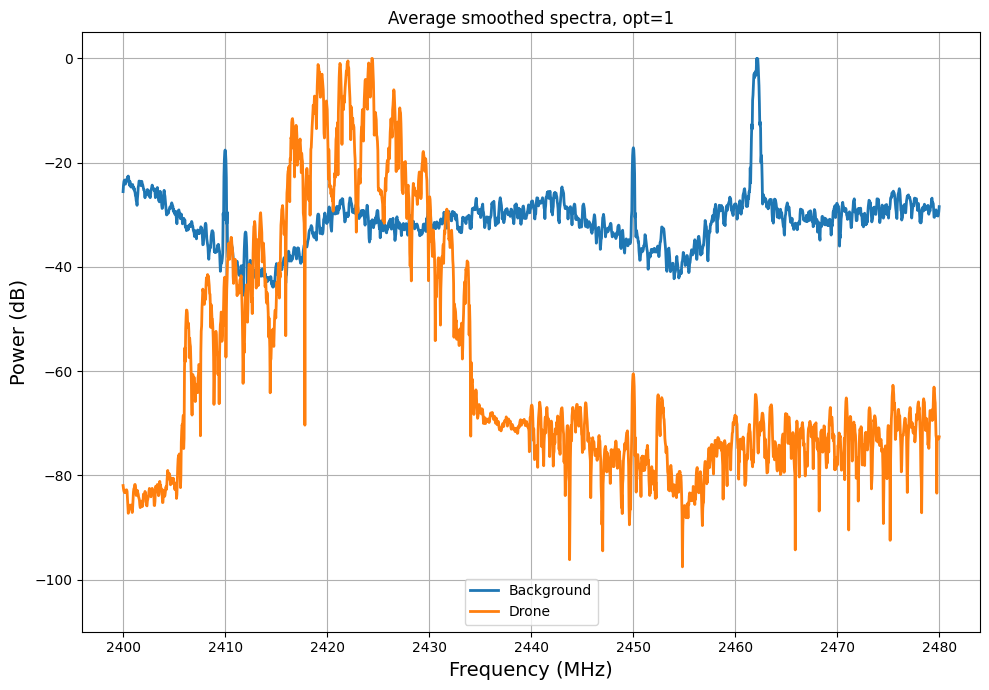

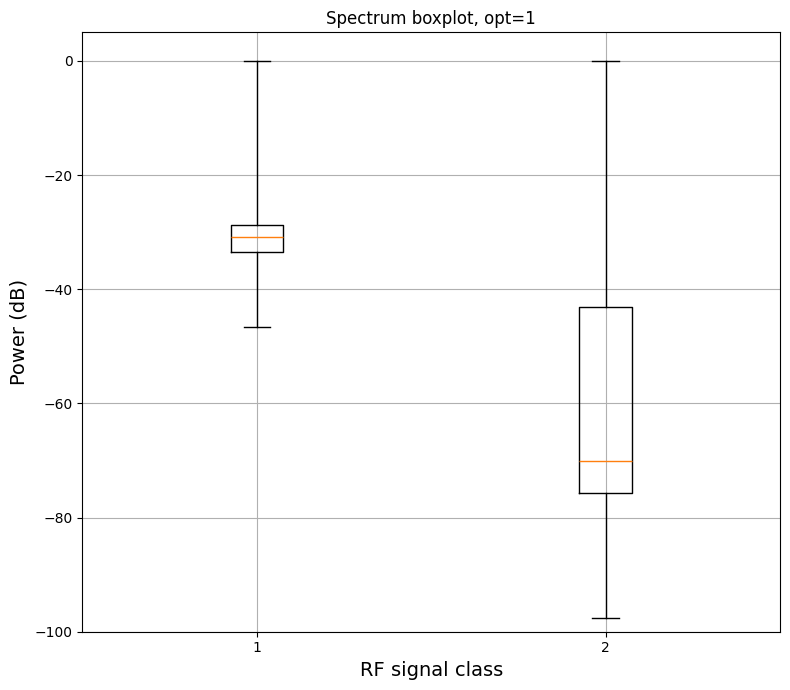

Saved: /content/drive/MyDrive/DroneRF/results2/Spectrum_2.pdf
Saved: /content/drive/MyDrive/DroneRF/results2/Box_2.pdf


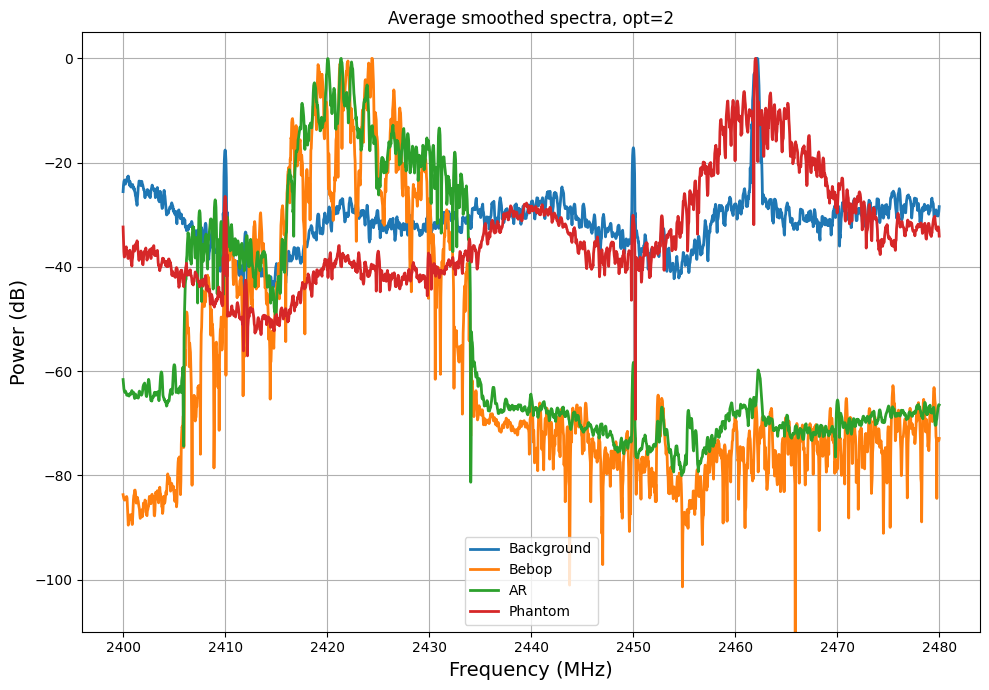

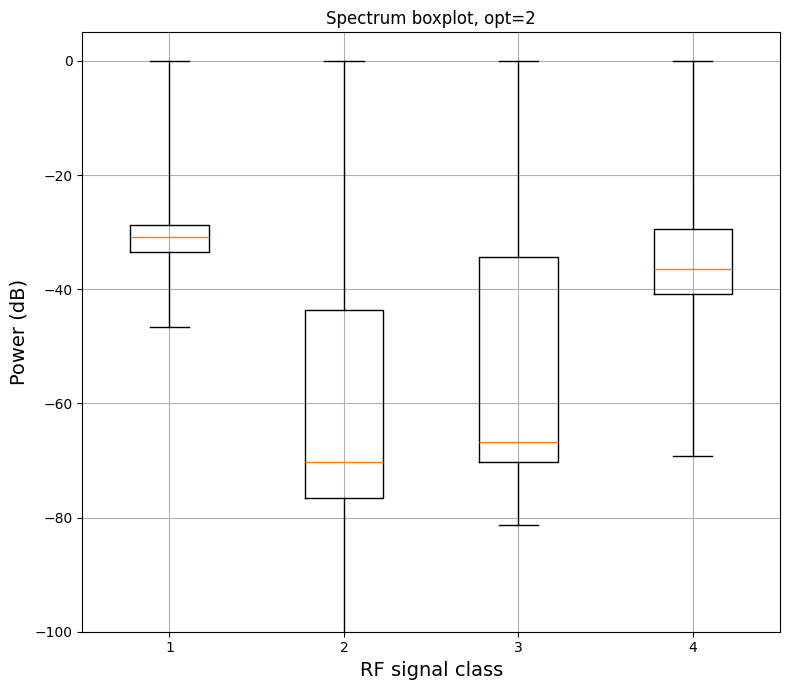

Saved: /content/drive/MyDrive/DroneRF/results2/Spectrum_3.pdf
Saved: /content/drive/MyDrive/DroneRF/results2/Box_3.pdf


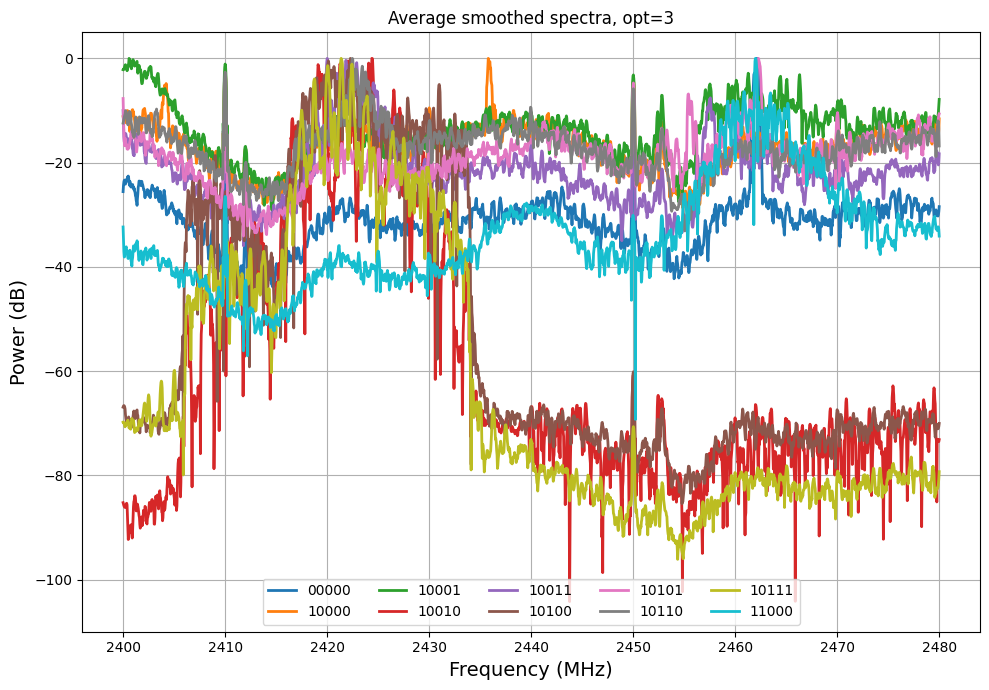

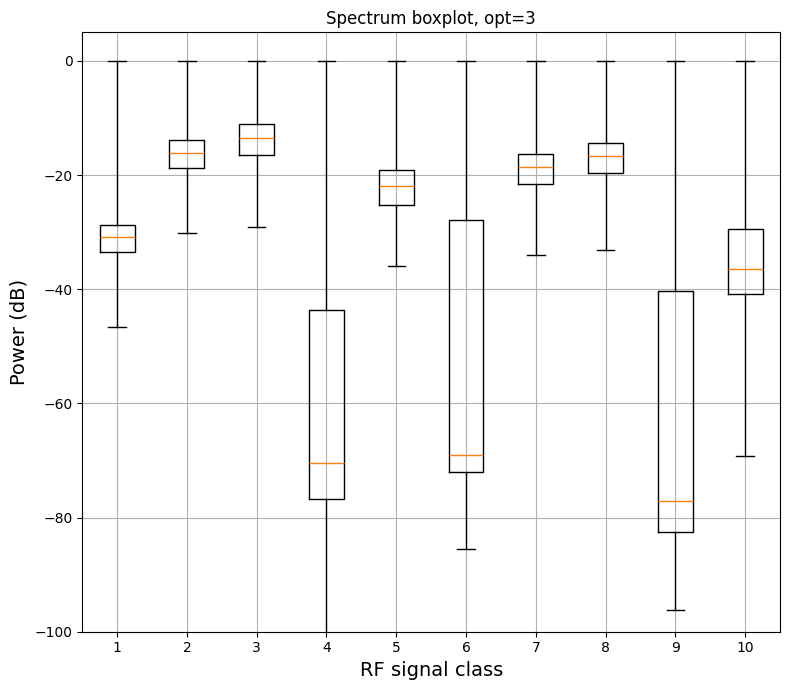

In [11]:
# =========================
# 7. Demo 3: spectrum analysis
# =========================

def demo3_analysis(load_directory=RESULTS_DIR, save_directory=RESULTS_DIR, opt=3, save_figures=False):
    load_directory = Path(load_directory)
    save_directory = ensure_dir(save_directory)

    BUI = ['00000', '10000', '10001', '10010', '10011',
           '10100', '10101', '10110', '10111', '11000']

    M = 2048
    fs = 80
    f = 2400 + np.linspace(0, fs, M)
    S = 10

    s = np.zeros((len(BUI), M))

    for i, bui in enumerate(BUI):
        mat_path = check_file(load_directory / f'{bui}.mat')
        x = loadmat(mat_path)['Data']
        s[i, :] = np.mean(x, axis=1)

    if opt == 1:
        sig = np.zeros((2, M))
        sig[0, :] = s[0, :]
        sig[1, :] = np.mean(s[1:, :], axis=0)
        class_names = ["Background", "Drone"]
    elif opt == 2:
        sig = np.zeros((4, M))
        sig[0, :] = s[0, :]
        sig[1, :] = np.mean(s[1:5, :], axis=0)
        sig[2, :] = np.mean(s[5:9, :], axis=0)
        sig[3, :] = s[9, :]
        class_names = ["Background", "Bebop", "AR", "Phantom"]
    elif opt == 3:
        sig = s
        class_names = BUI
    else:
        raise ValueError("opt must be 1, 2, or 3")

    sig_smooth = np.zeros_like(sig)
    for i in range(sig.shape[0]):
        window = S if S % 2 == 1 else S + 1
        sig_smooth[i, :] = savgol_filter(sig[i, :], window, 3)
        sig_smooth[i, sig_smooth[i, :] < 0] *= -1

    plt.figure(figsize=(10, 7))
    for i in range(sig.shape[0]):
        plt.plot(
            f,
            20 * np.log10(sig_smooth[i, :] / np.max(sig_smooth[i, :])),
            linewidth=2,
            label=class_names[i]
        )

    plt.xlabel('Frequency (MHz)', fontsize=14)
    plt.ylabel('Power (dB)', fontsize=14)
    plt.ylim(-110, 5)
    plt.grid(True)
    plt.legend(ncol=5 if opt == 3 else 1, loc='lower center')
    plt.title(f"Average smoothed spectra, opt={opt}")
    plt.tight_layout()

    if save_figures:
        out = save_directory / f"Spectrum_{opt}.pdf"
        plt.savefig(out, dpi=512)
        print("Saved:", out)

    plt.figure(figsize=(8, 7))
    plt.boxplot(
        20 * np.log10(sig_smooth / np.max(sig_smooth, axis=1)[:, np.newaxis]).T,
        whis=200
    )
    plt.xlabel('RF signal class', fontsize=14)
    plt.ylabel('Power (dB)', fontsize=14)
    plt.ylim(-100, 5)
    plt.grid(True)
    plt.title(f"Spectrum boxplot, opt={opt}")
    plt.tight_layout()

    if save_figures:
        out = save_directory / f"Box_{opt}.pdf"
        plt.savefig(out, dpi=512)
        print("Saved:", out)

    plt.show()

# Run Demo 3 after Main 1:
demo3_analysis(opt=1, save_figures=True)
demo3_analysis(opt=2, save_figures=True)
demo3_analysis(opt=3, save_figures=True)

# 8. Main 2: Data Labeling

This section loads the `.mat` files created by Main 1, normalizes them, concatenates them, adds labels, and saves:

```text
RF_Data.csv
```

The saved file contains:

- rows 0 to 2047: frequency-domain features  
- row 2048: Level 1 labels  
- row 2049: Level 2 labels  
- row 2050: Level 3 labels

In [12]:
# =========================
# 8. Main 2: data labeling
# =========================

def main2_data_labeling(load_directory=RESULTS_DIR, save_directory=RESULTS_DIR):
    load_directory = Path(load_directory)
    save_directory = ensure_dir(save_directory)

    BUI = [
        ['00000'],
        ['10000', '10001', '10010', '10011'],
        ['10100', '10101', '10110', '10111'],
        ['11000']
    ]

    DATA = None
    LN = []

    for t in range(len(BUI)):
        for b in range(len(BUI[t])):
            bui = BUI[t][b]
            print("Reading:", f"{bui}.mat")

            data_file = check_file(load_directory / f"{bui}.mat")
            myData = loadmat(data_file)
            Data = myData['Data']

            # Normalize each .mat file
            Data = Data / np.max(Data)

            if DATA is None:
                DATA = Data
            else:
                DATA = np.hstack((DATA, Data))

            LN.append(Data.shape[1])
            print(f"{bui}: shape={Data.shape}, LN={LN[-1]}")

    # Labeling
    Label = np.zeros((3, sum(LN)))

    # Level 1: 0 = background, 1 = drone
    Label[0, :] = np.concatenate([
        np.zeros(LN[0]),
        np.ones(sum(LN[1:]))
    ])

    # Level 2: 0 = background, 1 = Bebop, 2 = AR, 3 = Phantom
    Label[1, :] = np.concatenate([
        np.zeros(LN[0]),
        np.ones(sum(LN[1:5])),
        2 * np.ones(sum(LN[5:9])),
        3 * np.ones(LN[9])
    ])

    # Level 3: detailed 10-class BUI label index
    temp = np.concatenate([
        (i * np.ones(LN[i])).astype(int)
        for i in range(len(LN))
    ])
    Label[2, :] = temp

    output_path = save_directory / "RF_Data.csv"
    np.savetxt(output_path, np.vstack((DATA, Label)), delimiter=',')

    print("Saved:", output_path)
    print("Final DATA shape:", DATA.shape)
    print("Final Label shape:", Label.shape)

    return output_path

# Run Main 2 after Main 1:
rf_data_path = main2_data_labeling()

Reading: 00000.mat
00000: shape=(2048, 10), LN=10
Reading: 10000.mat
10000: shape=(2048, 10), LN=10
Reading: 10001.mat
10001: shape=(2048, 10), LN=10
Reading: 10010.mat
10010: shape=(2048, 10), LN=10
Reading: 10011.mat
10011: shape=(2048, 10), LN=10
Reading: 10100.mat
10100: shape=(2048, 10), LN=10
Reading: 10101.mat
10101: shape=(2048, 10), LN=10
Reading: 10110.mat
10110: shape=(2048, 10), LN=10
Reading: 10111.mat
10111: shape=(2048, 10), LN=10
Reading: 11000.mat
11000: shape=(2048, 10), LN=10
Saved: /content/drive/MyDrive/DroneRF/results2/RF_Data.csv
Final DATA shape: (2048, 100)
Final Label shape: (3, 100)


# 9. Load `RF_Data.csv` for Machine Learning

This section converts the original file format into the normal machine-learning format:

- `X`: features, shape = `(samples, features)`
- `y`: target labels, shape = `(samples,)`

Choose a classification level:

- `label_level=1`: Drone vs Background
- `label_level=2`: Drone family classification
- `label_level=3`: Detailed 10-class classification

In [36]:
# =========================
# 9. Load RF_Data.csv
# =========================

def load_rf_data(rf_data_path=RESULTS_DIR / "RF_Data.csv", label_level=3):
    rf_data_path = check_file(rf_data_path)

    print("Loading:", rf_data_path)
    Data = np.loadtxt(rf_data_path, delimiter=',')

    X = Data[0:2048, :].T

    if label_level == 1:
        y = Data[2048, :].astype(int)
        names = ["Background", "Drone"]
    elif label_level == 2:
        y = Data[2049, :].astype(int)
        names = ["Background", "Bebop", "AR", "Phantom"]
    elif label_level == 3:
        y = Data[2050, :].astype(int)
        names = ['00000', '10000', '10001', '10010', '10011',
                 '10100', '10101', '10110', '10111', '11000']
    else:
        raise ValueError("label_level must be 1, 2, or 3")

    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("Class counts:")
    print(pd.Series(y).value_counts().sort_index())

    return X, y, names

X, y, class_names = load_rf_data(label_level=1)

Loading: /content/drive/MyDrive/DroneRF/results2/RF_Data.csv
X shape: (100, 2048)
y shape: (100,)
Class counts:
0    10
1    90
Name: count, dtype: int64


# 10. Create a Small Stratified Subset

Instead of training on the entire dataset, we use a **small stratified random subset**.

Stratified means each class keeps roughly the same proportion as the original data.

In [37]:
# =========================
# 10. Small stratified subset
# =========================

def make_small_subset(X, y, subset_size=0.20, random_state=RANDOM_STATE):
    """
    Create a small stratified subset.

    subset_size can be:
    - a float such as 0.20 for 20% of the data
    - an int such as 500 for 500 total samples
    """

    X_small, _, y_small, _ = train_test_split(
        X,
        y,
        train_size=subset_size,
        stratify=y,
        random_state=random_state
    )

    print("Original size:", X.shape[0])
    print("Subset size:", X_small.shape[0])
    print("Subset class counts:")
    print(pd.Series(y_small).value_counts().sort_index())

    return X_small, y_small

X_small, y_small = make_small_subset(X, y, subset_size=0.80)

Original size: 100
Subset size: 80
Subset class counts:
0     8
1    72
Name: count, dtype: int64


# 11. What Are Classic ML Models?

In this project, students compare several classic ML models.

## Gaussian Naive Bayes
A simple probability-based model. It assumes features follow a Gaussian distribution.

## Logistic Regression
A linear classifier. Good baseline model for many classification problems.

## K-Nearest Neighbors
Classifies a sample based on the labels of nearby examples.

## Support Vector Machine
Finds a boundary that separates classes. Often strong for medium-sized datasets.

## Random Forest
Uses many decision trees and combines their predictions. Often strong and easy to explain.

In [38]:
# =========================
# 11. Train classic ML models
# =========================

def get_classic_models():
    models = {
        "Gaussian Naive Bayes": GaussianNB(),

        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),

        "K-Nearest Neighbors": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=5))
        ]),

        "Support Vector Machine": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE))
        ]),

        "Random Forest": RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    }

    return models


def train_and_evaluate_models(X, y, class_names=None, test_size=0.25):
    n_classes = len(np.unique(y))
    n_samples = len(y)

    # Make sure test set has at least 1 sample per class
    min_test_size = n_classes / n_samples

    if isinstance(test_size, float) and test_size < min_test_size:
        test_size = min_test_size
        print(f"Adjusted test_size to {test_size:.2f} so every class can appear in the test set.")

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=RANDOM_STATE
    )

    print("Training samples:", X_train.shape[0])
    print("Testing samples:", X_test.shape[0])

    models = get_classic_models()
    results = []
    predictions = {}

    for name, model in models.items():
        print_section(f"Training {name}")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="weighted")

        print("Accuracy:", round(acc, 4))
        print("Weighted F1:", round(f1, 4))
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, zero_division=0))

        results.append({
            "Model": name,
            "Accuracy": acc,
            "Weighted F1": f1
        })

        predictions[name] = (model, y_test, y_pred)

    results_df = pd.DataFrame(results).sort_values(
        by="Weighted F1",
        ascending=False
    ).reset_index(drop=True)

    return results_df, predictions

results_df, predictions = train_and_evaluate_models(X_small, y_small, class_names)
display(results_df)

Training samples: 60
Testing samples: 20

Training Gaussian Naive Bayes
Accuracy: 0.7
Weighted F1: 0.7562

Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.50      0.25         2
           1       0.93      0.72      0.81        18

    accuracy                           0.70        20
   macro avg       0.55      0.61      0.53        20
weighted avg       0.85      0.70      0.76        20


Training Logistic Regression
Accuracy: 0.6
Weighted F1: 0.675

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.86      0.67      0.75        18

    accuracy                           0.60        20
   macro avg       0.43      0.33      0.38        20
weighted avg       0.77      0.60      0.68        20


Training K-Nearest Neighbors
Accuracy: 0.8
Weighted F1: 0.8275

Classification Report:
              precision    recall  f1-sco

,Model,Accuracy,Weighted F1
0,Random Forest,0.9,0.852632
1,Support Vector Machine,0.9,0.852632
2,K-Nearest Neighbors,0.8,0.827451
3,Gaussian Naive Bayes,0.7,0.756250
4,Logistic Regression,0.6,0.675000


# 12. DNN Classification

This section uses a Deep Neural Network (DNN) to classify drone RF signals. A DNN is a machine learning model made of multiple layers of artificial neurons. Each layer learns patterns from the input data and passes those patterns to the next layer. In this project, the input data is the processed RF signal features from the DroneRF dataset, and the output is the predicted drone class.

Before training the DNN, the features are standardized using `StandardScaler`. This means each feature is transformed so that it has a similar scale. Scaling is important for neural networks because large feature values can make training unstable or slow.

The labels are converted using `to_categorical`, which changes class numbers into one-hot encoded vectors. For example, if we are using Level 3 classification with 10 classes, a label like `3` becomes a vector where only the fourth position is 1 and the rest are 0. This format works with the final `softmax` output layer.

The model is built using Keras `Sequential`, meaning the layers are stacked one after another. The first dense layer has 256 neurons and uses ReLU activation. The second dense layer has 128 neurons and also uses ReLU activation. ReLU helps the model learn nonlinear patterns in the RF signal data.

After each dense layer, the model uses `BatchNormalization` and `Dropout`. Batch normalization helps stabilize and speed up training by normalizing values inside the network. Dropout randomly turns off 30% of neurons during training, which helps prevent overfitting. Overfitting happens when a model memorizes the training data but performs poorly on new data.

The final dense layer uses `softmax`, which outputs a probability for each class. The class with the highest probability becomes the model’s prediction. The model is trained using the Adam optimizer and categorical cross-entropy loss, which are commonly used for multi-class classification problems.

This section also uses stratified K-fold cross-validation. Instead of training and testing only once, the data is split into multiple folds. Each fold keeps the class distribution balanced, so every class is represented. The model trains and evaluates several times, and the final average accuracy gives a more reliable estimate of performance.

In [39]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

def run_better_dnn_classification(
    X,
    y,
    opt=3,
    save_directory=RESULTS_DIR,
    n_splits=3,
    epochs=25,
    batch_size=16
):
    save_directory = ensure_dir(save_directory)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    y_cat = to_categorical(y)
    kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    scores = []

    for fold, (train_idx, test_idx) in enumerate(kfold.split(X_scaled, y), start=1):
        print_section(f"DNN Fold {fold}")

        model = Sequential([
            Dense(256, input_dim=X_scaled.shape[1], activation="relu"),
            BatchNormalization(),
            Dropout(0.3),

            Dense(128, activation="relu"),
            BatchNormalization(),
            Dropout(0.3),

            Dense(y_cat.shape[1], activation="softmax")
        ])

        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss="categorical_crossentropy",
            metrics=["accuracy"]
        )

        model.fit(
            X_scaled[train_idx],
            y_cat[train_idx],
            epochs=epochs,
            batch_size=batch_size,
            verbose=1
        )

        loss, acc = model.evaluate(X_scaled[test_idx], y_cat[test_idx], verbose=0)
        scores.append(acc)

        print("Fold accuracy:", acc)

        y_pred = model.predict(X_scaled[test_idx])
        output = np.column_stack((y_cat[test_idx], y_pred))

        out_path = save_directory / f"Results_{opt}{fold}.csv"
        np.savetxt(out_path, output, delimiter=",", fmt="%s")
        print("Saved:", out_path)

    print("Average DNN accuracy:", np.mean(scores))
    return scores


dnn_scores = run_better_dnn_classification(
    X_small,
    y_small,
    opt=1,
    n_splits=3,
    epochs=25
)


DNN Fold 1
Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.3962 - loss: 1.0817
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4906 - loss: 1.2306
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5849 - loss: 0.8833
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6792 - loss: 0.7748
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7547 - loss: 0.6173
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5472 - loss: 0.7377
Epoch 7/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7925 - loss: 0.4639
Epoch 8/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6792 - loss: 0.7450
Epoch 9/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7736 - loss: 0.6069
Epoch 10/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6226 - loss: 0.7722
Epoch 11/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6981 - loss: 0.6024
Epoch 12/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8491 - lo

# 13. Visualize Model Comparison

This section creates bar charts comparing the models.

,Model,Accuracy,Weighted F1
0,Random Forest,0.900,0.852632
1,Support Vector Machine,0.900,0.852632
2,K-Nearest Neighbors,0.800,0.827451
3,Gaussian Naive Bayes,0.700,0.756250
4,Logistic Regression,0.600,0.675000
5,Deep Neural Network,0.875,0.840000


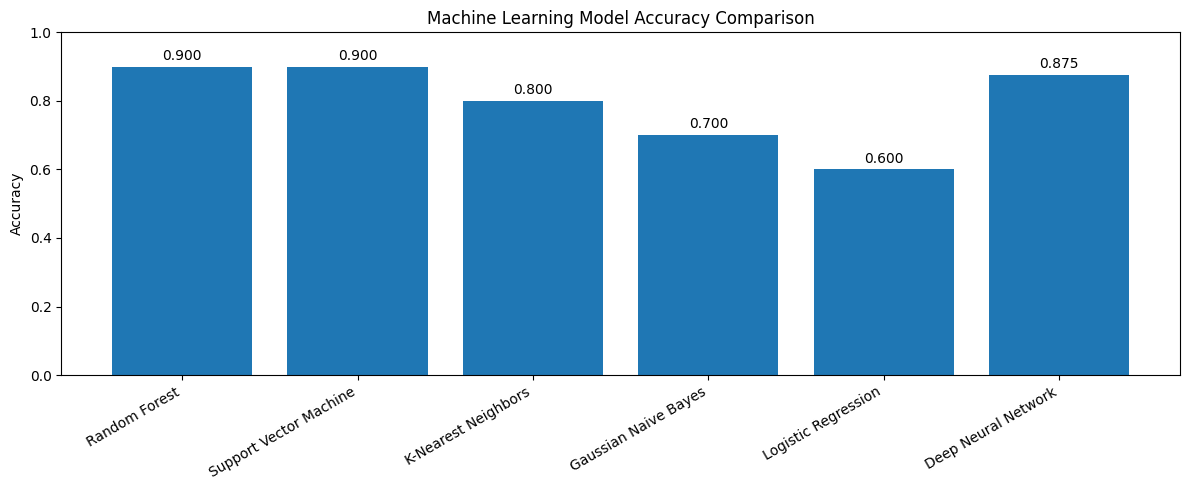

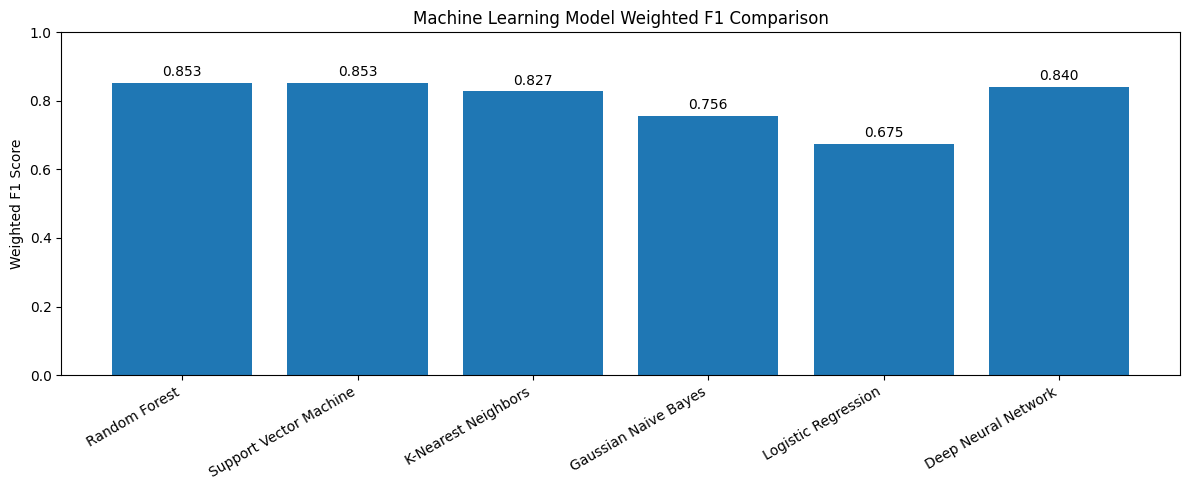

In [40]:
# =========================
# 12. Model comparison plot
# =========================

def compute_dnn_metrics(load_directory=RESULTS_DIR, opt=1, n_splits=3):
    load_directory = Path(load_directory)

    all_rows = []

    for fold in range(1, n_splits + 1):
        path = load_directory / f"Results_{opt}{fold}.csv"

        if path.exists():
            all_rows.append(np.loadtxt(path, delimiter=","))
        else:
            print("Missing:", path)

    if len(all_rows) == 0:
        raise FileNotFoundError("No DNN result files found.")

    y_all = np.vstack(all_rows)

    n_classes = y_all.shape[1] // 2

    y_true = np.argmax(y_all[:, :n_classes], axis=1)
    y_pred = np.argmax(y_all[:, n_classes:], axis=1)

    dnn_acc = accuracy_score(y_true, y_pred)
    dnn_f1 = f1_score(y_true, y_pred, average="weighted")

    return dnn_acc, dnn_f1


def plot_model_comparison(results_df, dnn_scores=None, include_dnn=True, opt=1, n_splits=3):

    results_plot = results_df.copy()

    if include_dnn:
        dnn_acc, dnn_f1 = compute_dnn_metrics(
            load_directory=RESULTS_DIR,
            opt=opt,
            n_splits=n_splits
        )

        dnn_row = pd.DataFrame([{
            "Model": "Deep Neural Network",
            "Accuracy": dnn_acc,
            "Weighted F1": dnn_f1
        }])

        results_plot = pd.concat(
            [results_plot, dnn_row],
            ignore_index=True
        )

    display(results_plot)

    # Accuracy comparison
    plt.figure(figsize=(12, 5))
    plt.bar(results_plot["Model"], results_plot["Accuracy"])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.title("Machine Learning Model Accuracy Comparison")

    for i, v in enumerate(results_plot["Accuracy"]):
        plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

    plt.tight_layout()
    plt.show()

    # Weighted F1 comparison
    plt.figure(figsize=(12, 5))
    plt.bar(results_plot["Model"], results_plot["Weighted F1"])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Weighted F1 Score")
    plt.ylim(0, 1)
    plt.title("Machine Learning Model Weighted F1 Comparison")

    for i, v in enumerate(results_plot["Weighted F1"]):
        plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

    plt.tight_layout()
    plt.show()


plot_model_comparison(results_df, include_dnn=True, opt=1, n_splits=3)

# 14. Confusion Matrices

A confusion matrix shows which classes the model predicts correctly and which classes it confuses.

Rows usually represent the true class. Columns represent the predicted class.

<Figure size 700x600 with 0 Axes>

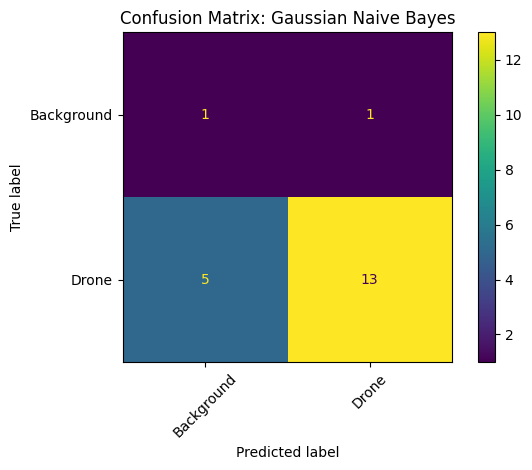

<Figure size 700x600 with 0 Axes>

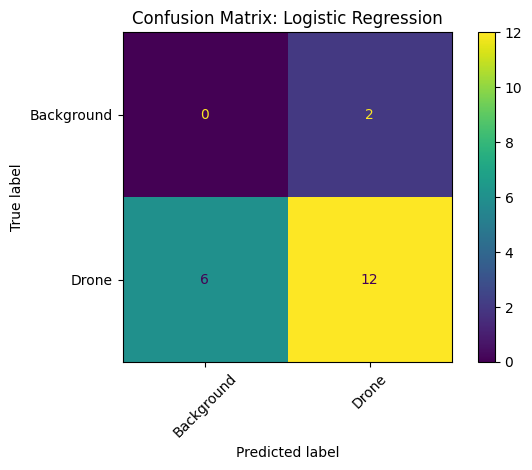

<Figure size 700x600 with 0 Axes>

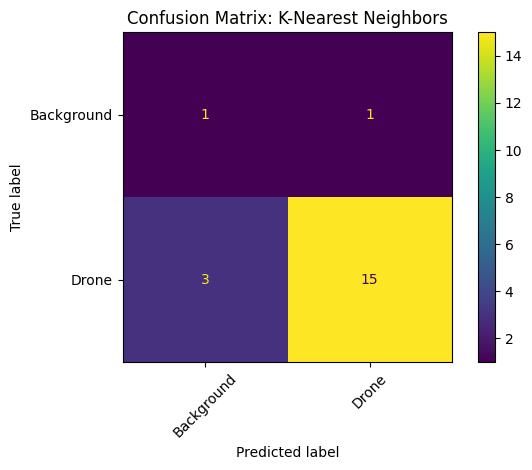

<Figure size 700x600 with 0 Axes>

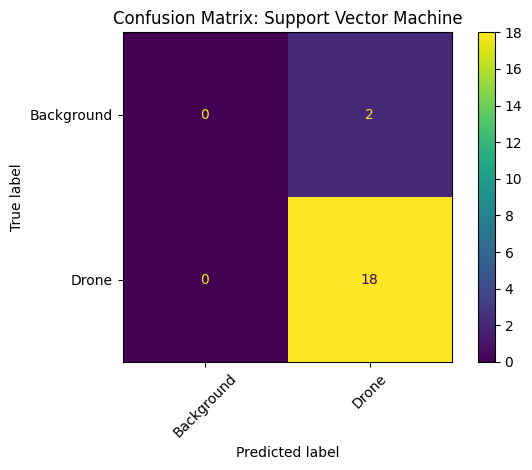

<Figure size 700x600 with 0 Axes>

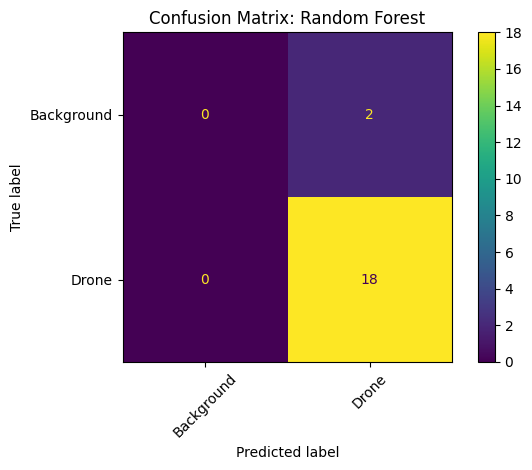

<Figure size 700x600 with 0 Axes>

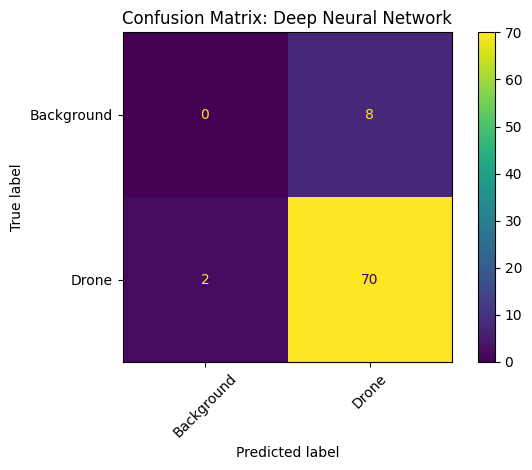

In [41]:
# =========================
# 14. Confusion matrix visualization
# =========================

def plot_confusion_matrices(predictions, class_names=None):

    for model_name, (model, y_test, y_pred) in predictions.items():

        labels = np.unique(np.concatenate([y_test, y_pred]))

        if class_names is not None and len(class_names) >= len(labels):
            display_labels = [class_names[int(i)] for i in labels]
        else:
            display_labels = labels

        cm = confusion_matrix(y_test, y_pred, labels=labels)

        plt.figure(figsize=(7, 6))

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=display_labels
        )

        disp.plot(values_format="d", xticks_rotation=45)
        plt.title(f"Confusion Matrix: {model_name}")
        plt.tight_layout()
        plt.show()


def plot_dnn_confusion_matrix(load_directory=RESULTS_DIR, opt=1, class_names=None):

    load_directory = Path(load_directory)

    all_rows = []

    for fold in range(1, 4):  # because your DNN uses n_splits=3
        path = load_directory / f"Results_{opt}{fold}.csv"

        if path.exists():
            all_rows.append(np.loadtxt(path, delimiter=","))
        else:
            print("Missing:", path)

    if len(all_rows) == 0:
        print("No DNN result files found.")
        return

    y_all = np.vstack(all_rows)

    n_classes = y_all.shape[1] // 2

    y_true = np.argmax(y_all[:, :n_classes], axis=1)
    y_pred = np.argmax(y_all[:, n_classes:], axis=1)

    labels = np.arange(n_classes)

    if class_names is not None and len(class_names) >= n_classes:
        display_labels = class_names[:n_classes]
    else:
        display_labels = labels

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(7, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_labels
    )

    disp.plot(values_format="d", xticks_rotation=45)
    plt.title("Confusion Matrix: Deep Neural Network")
    plt.tight_layout()
    plt.show()


# Classic ML confusion matrices
plot_confusion_matrices(predictions, class_names)

# DNN confusion matrix
plot_dnn_confusion_matrix(
    load_directory=RESULTS_DIR,
    opt=1,
    class_names=class_names
)

# 15. Student Reflection Questions

Answer these after running the notebook.

1. Which model had the highest accuracy?
2. Which model had the highest weighted F1-score?
3. Did any model confuse one drone class with another?
4. Why might RF signals be useful for drone detection?
5. Why is it important to use a small subset before running the full dataset?
6. What ethical concerns might come up when detecting drones using RF signals?
7. What would you try next to improve performance?